# Estimación de párametros del modelo SIR usando un AG

### Optimización con el algoritmo genético

In [6]:
import numpy as np
import random
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.interpolate import interp1d

In [ ]:
# problem constants:
DIMENSIONS = 2  # number of dimensions
BOUND_LOW, BOUND_UP = 0.0, 1.0  # boundaries for all dimensions

In [ ]:
# Genetic Algorithm constants:
POPULATION_SIZE = 100
P_CROSSOVER = 0.9  # probability for crossover
P_MUTATION = 0.45  # (try also 0.5) probability for mutating an individual
MAX_GENERATIONS = 500
HALL_OF_FAME_SIZE = 1
CROWDING_FACTOR = 1.0  # crowding factor for crossover and mutation

# set the random seed:
#RANDOM_SEED = 42
#random.seed(RANDOM_SEED)

In [ ]:
# Sistema de ecuaciones del modelo SIR.
def deriv(Y, t, N, a, b):
    S, I, R = Y
    dSdt = -a * S * I
    dIdt = a * S * I - b * I
    dRdt = b * I
    return dSdt, dIdt, dRdt

In [9]:
# Esta funcion calcula la distancia Manhattan entre los datos numericos y los reales.

def manhattan(individual):
    x = individual[0]
    y = individual[1]

    N = 763

    I0, R0 = 1, 0
    S0 = N - I0 - R0
    t = np.linspace(0, 15, 15)

    y0 = S0, I0, R0

    ret = odeint(deriv, y0, t, args=(N, x, y))
    S, I, R = ret.T


#    delta = np.absolute(ret.T[1] - datos_school)
#    f = np.sum(delta)

    delta = (np.absolute(ret.T[1] - datos_school)**2)/ret.T[1]
    f = np.sum(delta)

    return f,

In [10]:
datos_school = [1, 3, 6, 25, 73, 222, 294, 258, 237, 191, 125, 69, 27, 11, 4 ]

In [14]:
def funcion_objetivo(x_0, x_1):

    N = 763
    I0, R0 = 1, 0
    S0 = N - I0 - R0
    t = np.linspace(0, 15, 15)

    y0 = S0, I0, R0


    def deriv(y, t, N, beta, gamma):
        S, I, R = y
        dSdt = -beta * S * I
        dIdt = beta * S * I - gamma * I
        dRdt = gamma * I
        return dSdt, dIdt, dRdt

    ret = odeint(deriv, y0, t, args=(N, x_0, x_1))
    S, I, R = ret.T


#    datos = ret.T[1]
#    print(ret.T[1])

    fig = plt.figure(facecolor='w')
    ax = fig.add_subplot(111, axisbelow='line')
    ax.plot(datos_school, 'ro', alpha=0.5, lw=2, label='Data')
#    ax.plot(t, ret.T[1], 'b', alpha=0.5, lw=2, label='Best fitness')
    f2 = interp1d(t, ret.T[1], kind='cubic')
    t = np.linspace(0, 15, num=101)
    ax.plot(t, f2(t), 'b', alpha=0.5, lw=2, label='Best fit')
    ax.set_xlabel('t', fontsize=15)
    ax.set_ylabel('I(t)', fontsize=15)
    #ax.set_title("GA's approximation", fontsize=15)
    ax.legend()
    plt.grid(gridOn = False)
    fig.savefig('best_fit.png')
    plt.show()

    delta = np.absolute(ret.T[1] - datos_school)
    manhattan = np.sum(delta)
    f = manhattan

    return(f)

ValueError: keyword grid_b is not recognized; valid keywords are ['size', 'width', 'color', 'tickdir', 'pad', 'labelsize', 'labelcolor', 'labelfontfamily', 'zorder', 'gridOn', 'tick1On', 'tick2On', 'label1On', 'label2On', 'length', 'direction', 'left', 'bottom', 'right', 'top', 'labelleft', 'labelbottom', 'labelright', 'labeltop', 'labelrotation', 'grid_agg_filter', 'grid_alpha', 'grid_animated', 'grid_antialiased', 'grid_clip_box', 'grid_clip_on', 'grid_clip_path', 'grid_color', 'grid_dash_capstyle', 'grid_dash_joinstyle', 'grid_dashes', 'grid_data', 'grid_drawstyle', 'grid_figure', 'grid_fillstyle', 'grid_gapcolor', 'grid_gid', 'grid_in_layout', 'grid_label', 'grid_linestyle', 'grid_linewidth', 'grid_marker', 'grid_markeredgecolor', 'grid_markeredgewidth', 'grid_markerfacecolor', 'grid_markerfacecoloralt', 'grid_markersize', 'grid_markevery', 'grid_mouseover', 'grid_path_effects', 'grid_picker', 'grid_pickradius', 'grid_rasterized', 'grid_sketch_params', 'grid_snap', 'grid_solid_caps

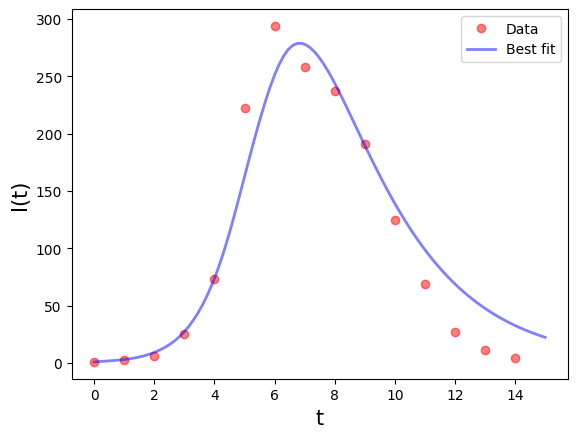

In [13]:
funcion_objetivo(0.002047488430022274, 0.4355147691971053)